In [51]:
import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy.wcs import WCS


LINUX_DIRECTORY = "/home/u20482jg/MPHYS_Project_Local"


COMAP_LIMITS = [(15, 150),(-1.1, 1.1)] # l limits, b limits
l_min = COMAP_LIMITS[0][0]
l_max = COMAP_LIMITS[0][1]
b_min = COMAP_LIMITS[1][0]
b_max = COMAP_LIMITS[1][1]

comap_maps = {
    "COMAP 26.5 GHz": "comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 27.5 GHz": "comap_160625_band01_band01_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 28.5 GHz": "comap_160625_band02_band02_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 29.5 GHz": "comap_160625_band03_band03_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 30.5 GHz": "comap_160625_band04_band04_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 31.5 GHz": "comap_160625_band05_band05_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 32.5 GHz": "comap_160625_band06_band06_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits",
    "COMAP 33.5 GHz": "comap_160625_band07_band07_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits"
}
comap_keys = list(comap_maps.keys())


fluxden_thres = 2 # Jy
theta_thres = 4 # arcmin

raw_catalogue = np.genfromtxt(f"{LINUX_DIRECTORY}/data/Paladini_catalogue.tsv",
                              delimiter=';', dtype='str', skip_header=3)


# include only sources within comap map range
cutout_catalogue = np.empty_like(raw_catalogue[0,:])
for i, l_val in enumerate(raw_catalogue[:,0]):
    if ((l_min < float(l_val) < l_max) and
        (b_min < float(raw_catalogue[i,1]) < b_max)):
        cutout_catalogue = np.vstack((cutout_catalogue, raw_catalogue[i,:]))

cutout_catalogue = cutout_catalogue[1:,:] # Remove nonsense first row from np.empty_like


bright_catalogue = np.empty_like(cutout_catalogue[0,:])
for i, S in enumerate(cutout_catalogue[:,7]):
    if float(S) > fluxden_thres:
        bright_catalogue = np.vstack((bright_catalogue, cutout_catalogue[i,:]))

bright_catalogue = bright_catalogue[1:,:] # Remove nonsense first row from np.empty_like

print(f"Remaining after flux density cut: {len(bright_catalogue[:,0])}")


ps_catalogue = np.empty_like(bright_catalogue[0,:])
for i, theta in enumerate(bright_catalogue[:,11]):
    if float(theta) < theta_thres:
        ps_catalogue = np.vstack((ps_catalogue, bright_catalogue[i,:]))

ps_catalogue = ps_catalogue[1:,:] # Remove nonsense first row from np.empty_like

print(f"Remaining after angular size cut: {len(ps_catalogue[:,0])}")

Remaining after flux density cut: 282
Remaining after angular size cut: 85


In [52]:
def cutout_map(data, wcs, l_bounds, b_bounds):
    upper_l, lower_b = wcs.all_world2pix(l_bounds[0], b_bounds[0], 0)
    lower_l, upper_b = wcs.all_world2pix(l_bounds[1], b_bounds[1], 0)

    if lower_l < 0:
        lower_l = 0
    if lower_b < 0:
        lower_b = 0
    print(lower_l, lower_b)
    print(upper_l, upper_b)

    cutout = data[int(lower_b):int(upper_b)+1,
                  int(lower_l):int(upper_l)+1].copy()
    cutout[cutout==np.nan] = 0

    new_header = fits.Header()
    new_header['CTYPE1'] = wcs.wcs.ctype[0]
    new_header['CTYPE2'] = wcs.wcs.ctype[1]
    new_header['CRVAL1'] = l_bounds[1]
    new_header['CRVAL2'] = b_bounds[0]
    new_header['CRPIX1'] = 1
    new_header['CRPIX2'] = 1
    new_header['PC1_1'] = 1.0
    new_header['PC1_2'] = 0.0
    new_header['PC2_1'] = 0.0
    new_header['PC2_2'] = 1.0
    new_header['CDELT1'] = wcs.wcs.cdelt[0]
    new_header['CDELT2'] = wcs.wcs.cdelt[1]
    new_header['NAXIS1'] = upper_l - lower_l
    new_header['NAXIS2'] = upper_b - lower_b
    new_wcs = WCS(new_header)
    print(f"Cutout WCS:\n {new_wcs}")
    # print(cutout)

    return cutout, new_header, new_wcs


def get_map(path, l_bounds=None, b_bounds=None, layer=0):
    print(f"Getting data from {path}")
    fits_file = fits.open(path)
    data = fits_file[layer].data * 1000 # convert to mK
    header = fits_file[layer].header
    wcs = WCS(header)

    if l_bounds and b_bounds is not None:
        return cutout_map(data, wcs, l_bounds, b_bounds)
    
    else:
        print("Raw WCS:\n {wcs}")
        return data, header, wcs

Getting data from /home/u20482jg/MPHYS_Project_Local/data/comap_maps/comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits
Raw WCS:
 {wcs}
Getting data from /home/u20482jg/MPHYS_Project_Local/data/comap_maps/comap_160625_band00_band00_feed01-02-03-04-05-06-07-08-09-11-12-13-14-15-16-17-18-19.fits
Raw WCS:
 {wcs}


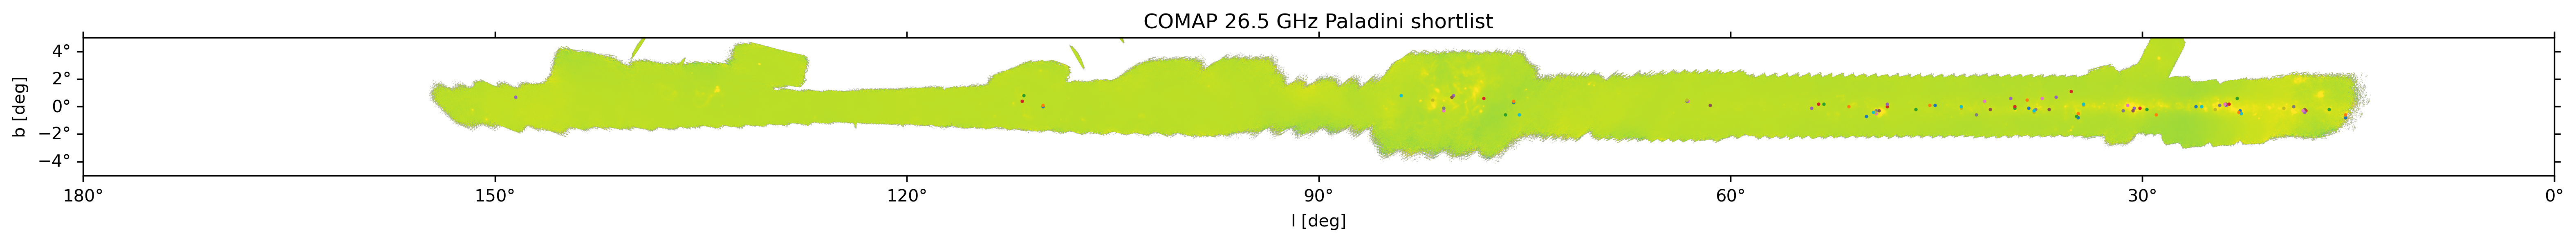

In [53]:
fname = comap_maps[comap_keys[0]]

path = f"{LINUX_DIRECTORY}/data/comap_maps/{fname}"
comap_data, comap_header, comap_wcs\
        = get_map(path)
comap_noise, hdump, wcsdump = get_map(path)

comap_error = 0.05*comap_data

fig, ax = plt.subplots(1, 1, figsize=(26,2), dpi=300,
                       subplot_kw={'projection': comap_wcs})

v_min = np.nanpercentile(comap_data, 0.)
v_max = np.nanpercentile(comap_data, 99.5)

im = ax.imshow(comap_data, origin='lower', cmap='viridis', vmin = v_min,
               vmax = v_max)

for i, l in enumerate(ps_catalogue[:,0]):
    l_pix, b_pix = comap_wcs.all_world2pix(float(l), float(ps_catalogue[i,1]), 0)
    ax.scatter(l_pix, b_pix, s=1)

ax.set_title(f"{comap_keys[0]} Paladini shortlist")
ax.set_xlabel("l [deg]")
ax.set_ylabel("b [deg]")



In [ ]:
OMITTED_IDS = [
    203,
    204,
    211,
    231,
    233,
    236,
    253,
    261,
    284,
    286,
    288,
    300,
    303
]


radial_stampsize = 8 # pix

nearest_square = np.ceil(np.sqrt(len(ps_catalogue[:,0])))
print(nearest_square)

fig, axes = plt.subplots(int(nearest_square), int(nearest_square),
                        figsize = (2.5*nearest_square,
                                   2.5*nearest_square),
                        dpi=300)

for i, l in enumerate(ps_catalogue[:,0]):
    # Getting standard gal coords nomenclature
    if float(l) < 10:
        pre_l = "00"
    elif float(l) < 100:
        pre_l = "0"
    else:
        pre_l = ""
    if abs(float(ps_catalogue[i,1])) < 10:
        pre_b = "0"
    else:
        pre_b = ""
    if float(ps_catalogue[i,1]) >= 0:
        sign = "+"
        b_name = str(ps_catalogue[i,1])
    else:
        sign = "-"
        b_name = float(str(ps_catalogue[i,1])[1:])

    reg_id = ps_catalogue[i,2]
    reg_name = "G{0}{1:.3f}{2}{3}{4:.3f}".format(pre_l, float(l), sign, pre_b, float(b_name))

    b = ps_catalogue[i,1]
    theta_pix = float(ps_catalogue[i,11])/(comap_wcs.wcs.cdelt[1]*60)
    l_index, b_index = comap_wcs.all_world2pix(float(l),float(b),0)
    lower_l, lower_b = int(l_index - radial_stampsize), int(b_index - radial_stampsize)
    upper_l, upper_b = int(l_index + radial_stampsize), int(b_index + radial_stampsize)

    source_pos = (l_index - lower_l, b_index - lower_b)

    reg_cutout = np.flip(comap_data[lower_b:upper_b + 1, lower_l:upper_l + 1].copy(), 0)
    regnoise_cutout = np.flip(comap_data[lower_b:upper_b + 1, lower_l:upper_l + 1].copy(), 0)

    ax = axes[int(np.floor(i/nearest_square)), i%int(nearest_square)]
    im = ax.imshow(reg_cutout, origin='lower', cmap='viridis')
    ax.scatter(source_pos[0], source_pos[1], edgecolors="red",
               facecolors="none", s=theta_pix, linewidths=1)
    ax.set_title(f"{reg_id}: {reg_name}")
    ax.set_xlabel("l index [pix]")
    ax.set_ylabel("b index [pix]")

fig.tight_layout()

10.0
